# M8: gain vs. shape decomposition

Implements proposal 4 from `docs/ssvep_analyses.md` (PLAN milestone M8): is a
group's deficit a uniform gain reduction (the whole surface scaled down) or
something trough-specific (a chromatic shape change)? `analysis.fit_gain_shape`
fits `subject_grid ~= gain * CTR_template + intercept` per subject, over all
100 cells; `analysis.trough_region_residual` then asks whether what's left
over after removing that uniform gain is concentrated near the template's own
trough or spread evenly across the grid.

In [1]:
import sys
sys.path.append('../scripts')

import numpy as np
import pandas as pd
from scipy import stats

import analysis as an
import plotting

runmap_df = an.load_runmap()
baselines_df = an.load_baselines()
metadata_df = an.load_metadata()
red_vals, green_vals = an.load_grid_axes()

SESSION = 1
troughs_df = pd.read_csv('../files/subject_troughs.csv', keep_default_na=False)
s1 = troughs_df[troughs_df['session'] == SESSION]

## Understanding the gain/shape split

`fit_gain_shape` is ordinary linear regression -- `subject ~= gain*template +
intercept` -- but the slope and the residual carry a specific physical
meaning here. If a subject's surface really is just the template scaled up
or down (a uniform gain change), the regression should fit it almost
perfectly and the leftover residual should be small, unstructured noise
everywhere. If something *besides* scaling is going on -- a deficit specific
to one region, like the trough -- a uniform gain can't absorb that, so it
shows up as a residual concentrated in that region, not spread evenly. The
`gain` number alone can't tell these two situations apart; the residual's
*spatial pattern* is what does.


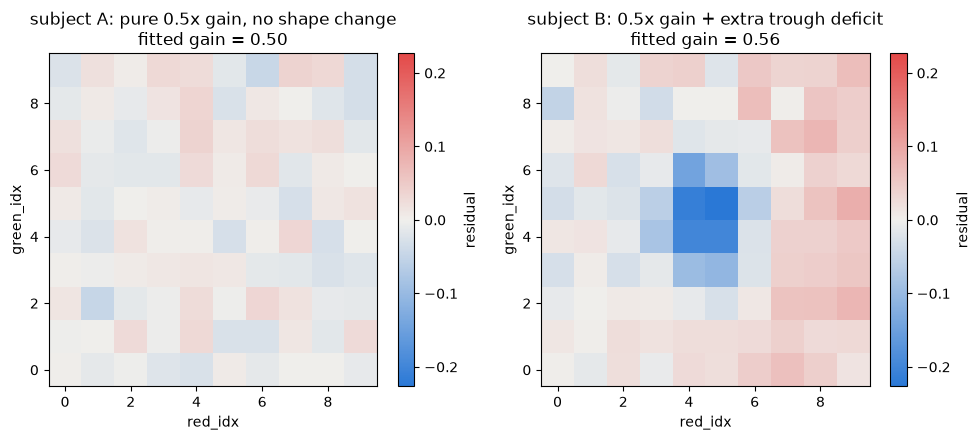

In [2]:
import matplotlib.pyplot as plt

rng_demo = np.random.default_rng(0)
red_demo = list(np.linspace(0, 3200, 10))
green_demo = list(np.linspace(0, 2000, 10))
Xg, Yg = np.meshgrid(red_demo, green_demo, indexing='ij')
template_demo = 2.0 - 0.0003 * Xg - 0.5 * np.exp(-(((Xg - 1600) ** 2) / (2 * 600.0 ** 2) + ((Yg - 1000) ** 2) / (2 * 400.0 ** 2)))

# subject A: a pure gain change, nothing else
subject_a = 0.5 * template_demo + rng_demo.normal(0, 0.02, template_demo.shape)
# subject B: the same gain change, plus an extra deficit localized at the trough
extra_deficit = 0.3 * np.exp(-(((Xg - 1600) ** 2) / (2 * 400.0 ** 2) + ((Yg - 1000) ** 2) / (2 * 300.0 ** 2)))
subject_b = 0.5 * template_demo - extra_deficit + rng_demo.normal(0, 0.02, template_demo.shape)

fit_a = an.fit_gain_shape(subject_a, template_demo)
fit_b = an.fit_gain_shape(subject_b, template_demo)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
vmax = max(np.abs(fit_a['residual']).max(), np.abs(fit_b['residual']).max())
for ax, fit, label in zip(axes, [fit_a, fit_b], ['subject A: pure 0.5x gain, no shape change', 'subject B: 0.5x gain + extra trough deficit']):
    im = ax.imshow(fit['residual'].T, origin='lower', cmap=plotting.DIVERGING_BLUE_RED, vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_title(f"{label}\nfitted gain = {fit['gain']:.2f}")
    ax.set_xlabel('red_idx'); ax.set_ylabel('green_idx')
    plt.colorbar(im, ax=ax, label='residual')
fig.tight_layout()

Both synthetic subjects are the same template scaled by 0.5 -- the fitted
`gain` comes out close to 0.5 for both (0.56 for subject B is pulled up
slightly by the extra deficit competing with the gain term in the same
regression, worth keeping in mind: `gain` and localized shape effects aren't
perfectly separable, just mostly so). The residual maps are where the real
difference shows up. Subject A's left panel is unstructured -- faint noise
scattered everywhere, no region standing out, because a pure gain change is
*by construction* exactly what this regression removes. Subject B's right
panel has an unmistakable blue patch sitting right where the extra deficit
was planted -- a uniform gain term cannot explain a hole in one specific
place, so it shows up as leftover residual concentrated exactly there. This
is the picture `trough_region_residual` turns into two numbers (mean
residual inside vs. outside that patch), and it's what the real protan
subjects' residuals looked like below, minus the synthetic clean setup.

## The reference template and its trough

The CTR group-mean grid (percent change, session 1) is the template every
subject gets regressed against. `trough_region_residual` needs a fixed pixel
to center its window on -- the template's own trough location, not each
subject's own (subjects whose own trough couldn't be located at all are
exactly the ones this analysis needs to still say something about).

In [3]:
template = an.group_grid(runmap_df, baselines_df, metadata_df, SESSION, group='CTR', normalize=an.DEFAULT_NORMALIZE)
template_trough = an.trough_location(template, red_vals, green_vals)
template_trough

{'red': 2133.3333333333335,
 'green': 888.8888888888889,
 'depth': np.float64(0.2464881067313479),
 'red_idx': np.int64(6),
 'green_idx': np.int64(4)}

## Fit every subject against the template

`gain=1` reproduces the template's own scale exactly, and CTR subjects
contribute to the template they're being fit against -- so CTR's own gain
distribution centering on 1 is a circularity check, not an independent
result. PD, protan, and deutan are the actual comparisons.

In [4]:
rows = []
for _, meta in s1.iterrows():
    grid = an.mean_grid(runmap_df, baselines_df, meta['sub_id'], SESSION, normalize=an.DEFAULT_NORMALIZE)
    fit = an.fit_gain_shape(grid, template)
    region = an.trough_region_residual(fit['residual'], template_trough['red_idx'], template_trough['green_idx'])
    rows.append({'sub_id': meta['sub_id'], 'group': meta['group'], 'subgroup': meta['subgroup'],
                 'gain': fit['gain'], 'intercept': fit['intercept'], 'r_squared': fit['r_squared'],
                 'trough_region_residual': region['trough_region'], 'rest_of_grid_residual': region['rest_of_grid']})

gain_shape_df = pd.DataFrame(rows)
gain_shape_df['category'] = np.select(
    [gain_shape_df['group'] == 'CTR', gain_shape_df['group'] == 'PD', gain_shape_df['subgroup'] == 'protan', gain_shape_df['subgroup'] == 'deutan'],
    ['CTR', 'PD', 'protan', 'deutan'],
    default=None,
)
compare_df = gain_shape_df.dropna(subset=['category'])
compare_df.groupby('category')[['gain', 'r_squared', 'trough_region_residual', 'rest_of_grid_residual']].describe().T

category                               CTR        PD    deutan    protan
gain                   count  2.100000e+01  6.000000  7.000000  8.000000
                       mean   1.000000e+00  1.051234  0.546459  0.547200
                       std    3.647004e-01  0.674101  0.372685  0.322963
                       min    4.088077e-01  0.322953  0.075733 -0.074745
                       25%    7.619076e-01  0.672625  0.301609  0.356677
                       50%    9.367382e-01  0.880113  0.365581  0.635493
                       75%    1.331773e+00  1.259461  0.874793  0.754585
                       max    1.602220e+00  2.234851  1.031096  0.923867
r_squared              count  2.100000e+01  6.000000  7.000000  8.000000
                       mean   5.511075e-01  0.531378  0.238408  0.179581
                       std    1.548506e-01  0.157212  0.183359  0.093270
                       min    2.842192e-01  0.256620  0.025025  0.002262
                       25%    4.538659e-01  0.525921  0.086895  0.165351
                       50%    5.239286e-01  0.547879  0.186893  0.216941
                       75%    6.790110e-01  0.565909  0.423553  0.235459
                       max    8.278035e-01  0.745367  0.436040  0.255490
trough_region_residual count  2.100000e+01  6.000000  7.000000  8.000000
                       mean  -4.427675e-17 -0.015708  0.012691 -0.104965
                       std    6.360438e-02  0.061630  0.066527  0.109036
                       min   -1.795273e-01 -0.111563 -0.089241 -0.321822
                       25%   -4.645684e-02 -0.052147 -0.018184 -0.137209
                       50%    1.104508e-02  0.002117  0.011612 -0.068046
                       75%    3.413343e-02  0.025495  0.048235 -0.048579
                       max    1.003572e-01  0.050030  0.106367  0.003562
rest_of_grid_residual  count  2.100000e+01  6.000000  7.000000  8.000000
                       mean  -1.402235e-16  0.001554 -0.001255  0.010381
                       std    6.290543e-03  0.006095  0.006580  0.010784
                       min   -9.925440e-03 -0.004948 -0.010520 -0.000352
                       25%   -3.375834e-03 -0.002521 -0.004770  0.004805
                       50%   -1.092371e-03 -0.000209 -0.001148  0.006730
                       75%    4.594632e-03  0.005157  0.001798  0.013570
                       max    1.775545e-02  0.011034  0.008826  0.031829

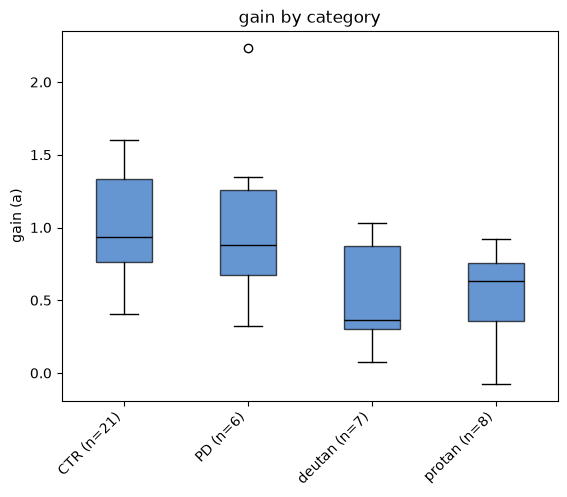

In [5]:
plotting.plot_troughs_boxplot(compare_df, 'gain', 'category', ylabel='gain (a)');

Protan and deutan both sit well below gain=1 (medians ~0.6 and ~0.4), with
low `r_squared` (median ~0.19-0.22) -- the CTR template's spatial pattern is
a poor predictor of either CVD subgroup's grid, which is exactly what you'd
expect if their trough sits somewhere the template's doesn't. PD's gain
(median 0.88) sits closer to CTR's own internal spread and its `r_squared`
(~0.55) matches CTR's own (~0.52) -- PD's *shape* resembles CTR's reasonably
well, just at a somewhat different (not reliably lower, per M7) scale.

Note this doesn't reproduce `docs/ssvep_analyses.md` proposal 1's "PD is 16%
below CTR in mean % change" number, and that's expected, not a
contradiction: proposal 1's number came from *trough depth* alone (a single
localized quantity), while `gain` here is a regression over the *whole*
100-cell grid, dominated by the ramp rather than the trough. They're
different statistics measuring different things and can legitimately diverge.

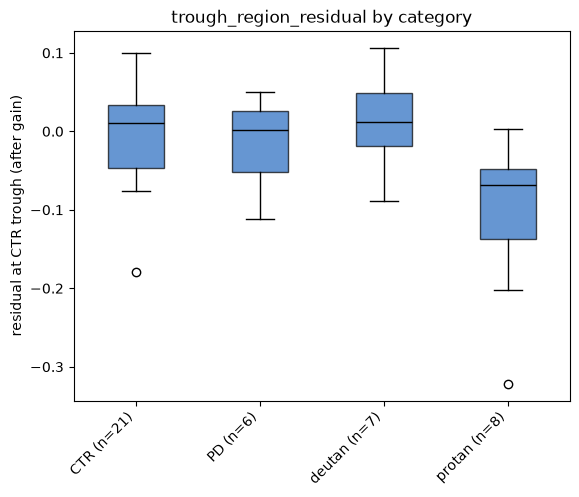

In [6]:
plotting.plot_troughs_boxplot(compare_df, 'trough_region_residual', 'category', ylabel='residual at CTR trough (after gain)');

In [7]:
for cat in ('PD', 'protan', 'deutan'):
    vals = compare_df.loc[compare_df['category'] == cat, 'trough_region_residual']
    t, p = stats.ttest_1samp(vals, 0)
    print(f"{cat:8s} n={len(vals)}  mean residual at CTR trough = {vals.mean():+.3f}  (one-sample t vs 0: t={t:.2f}, p={p:.3f})")

PD       n=6  mean residual at CTR trough = -0.016  (one-sample t vs 0: t=-0.62, p=0.560)
protan   n=8  mean residual at CTR trough = -0.105  (one-sample t vs 0: t=-2.72, p=0.030)
deutan   n=7  mean residual at CTR trough = +0.013  (one-sample t vs 0: t=0.50, p=0.632)


This is the result proposal 4 was actually asking for. PD's and deutan's
residuals at the CTR template's trough location are indistinguishable from
zero (p=0.56, p=0.63) -- once gain is removed, neither group has anything
*extra* going on there. **Protan's does not** (mean -0.10, p=0.030,
uncorrected, n=8): even after correcting for their overall gain, protan
subjects respond specifically less than predicted right at the location
where CTR's trough sits.

This fits together with M6 rather than standing alone. Protan had the
shallowest `ramp_slope_red` of the three groups (M6, `08_cvd_gamut.ipynb`) --
the group whose trough sits furthest beyond the sampled red range on average.
A protan subject's surface at the CTR template's trough location is
typically still on its own descending ramp, not yet recovering the way CTR's
template does past its own dip -- which is exactly a localized negative
residual at that one location, not a uniform gain effect. Deutan's trough
tends to sit closer to the sampled range (steeper `ramp_slope_red` than
protan's in M6), so there's less mismatch with the CTR template's trough
location left over after gain -- consistent with deutan showing no
trough-specific residual here.

## Cross-check against the ramp_gaussian fit's own measures

`ramp_intercept` (M6, `fit_ramp`) is an independent "gain-like" measure --
the ramp's overall level -- and `fitted_amp` (M4/M6, `fit_ramp_gaussian`) is
an independent "shape-like" measure -- the subject's own local dip depth
relative to their own ramp. Neither was built with this notebook's `gain`/
`trough_region_residual` in mind, so agreement (or disagreement) between them
is informative on its own.

In [8]:
merged = s1.merge(gain_shape_df[['sub_id', 'gain', 'trough_region_residual']], on='sub_id')

r_gain, p_gain = stats.pearsonr(merged['gain'], merged['ramp_intercept'])
r_shape, p_shape = stats.pearsonr(merged['trough_region_residual'], merged['fitted_amp'])
print(f"gain vs ramp_intercept:              r={r_gain:.2f}, p={p_gain:.1e}  (n={len(merged)})")
print(f"trough_region_residual vs fitted_amp: r={r_shape:.2f}, p={p_shape:.2f}  (n={len(merged)})")

gain vs ramp_intercept:              r=0.87, p=3.9e-14  (n=43)
trough_region_residual vs fitted_amp: r=0.04, p=0.79  (n=43)


The two gain measures agree strongly (r=0.87, p<1e-13) despite coming from
completely different fits (a 100-cell regression against an external CTR
template vs. a single subject's own ramp intercept) -- good evidence that
"gain" is a real, robustly-measurable axis in this data, not an artifact of
one particular fitting choice.

The two shape measures **don't** agree (r=0.04, p=0.79) -- and that's not a
failure of either one, it's because they're not measuring the same thing.
`fitted_amp` is *subject-centered*: the dip depth relative to that subject's
own ramp, wherever their dip actually is. `trough_region_residual` is
*template-centered*: the residual at one fixed external location (CTR's
trough), regardless of where the subject's own trough is. For a protan
subject whose real trough is far from CTR's, these can disagree completely --
which is exactly the situation `trough_region_residual` was built to detect
and `fitted_amp` was never designed to see. Use `fitted_amp` to ask "how deep
is this subject's own dip" and `trough_region_residual` to ask "does this
subject respond normally at *this* location" -- they answer different
questions.